# MSCViT (MSCViT-T) -- IQ-OTH/NCCD (224x224, 35 epochs, trained from scratch, NO early stopping)
Images pooled from the attached Kaggle mirror of the IQ-OTH/NCCD dataset (`Normal cases` / `Bengin cases` / `Malignant cases` folders, auto-detected under `/kaggle/input` by fuzzy folder-name matching), shuffled, and re-split stratified **60% train / 20% validation / 20% test** (`random_state=42`). 3 classes: normal, benign, malignant.

**Specifications for this run:**
- Image size: **224x224**
- Batch size: **16**
- Epochs: **35, always runs the full 35 -- no early stopping**
- Optimizer: **Adam, learning_rate=5e-4**
- **Trained from scratch (no pretrained weights)** -- every parameter is randomly initialized.
- **No data augmentation**, **no class weighting**, and **no ImageNet normalization** (`Resize` + `ToTensor` only, consistent with the reference notebook this model was copied from).

**Implementation note:** the MSCViT model code (config dict, `ConvStem`, `DWConv`, `LFE`, `ChannelMixer`, `MSCBlock`, `Stage`, `MSCViT`) is carried over **verbatim** from the reference notebook you supplied (`Mobile-exp120-mscvit-imbalance-pneu-dataset.ipynb`), only `NUM_CLASSES`/`DEVICE` wiring changed to fit this pipeline. Default variant is `MSCViT-T` (lightest of the 3 configs in that notebook); switch `MSCVIT_VARIANT` in the model cell to `"MSCViT-XS"` or `"MSCViT-S"` for a heavier ablation point.

**Note:** make sure the IQ-OTH/NCCD Kaggle dataset is attached to this notebook (Add Data) before running -- cell 0 will show it under `/kaggle/input` if it's attached correctly.

## 0. Explore /kaggle/input

In [5]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []
  datasets/  [0 files]  []
    hamdallak/  [0 files]  []
      the-iqothnccd-lung-cancer-dataset/  [0 files]  []
        The IQ-OTHNCCD lung cancer dataset/  [1 files]  ['IQ-OTH_NCCD lung cancer dataset.txt']


## 1. Install + Imports
No extra package needed for the model itself -- MSCViT is plain `torch.nn` code, no `timm`/`torchvision` model classes involved.

In [6]:
# no extra install needed -- MSCViT is defined from scratch with plain torch.nn below

In [7]:
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

TARGET_CLASSES = ['normal', 'benign', 'malignant']
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
CHECKPOINT_PATH = "best_mscvit_iqothnccd_224.pt"

Using device: cpu


## 2. Locate the IQ-OTH/NCCD dataset + build a dataframe

In [8]:
def fuzzy_map_class(folder_name):
    n = folder_name.lower()
    if "normal" in n:
        return "normal"
    if "benign" in n or "bengin" in n:
        return "benign"
    if "malignant" in n:
        return "malignant"
    return None

records = []
found_dirs = []
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    label = fuzzy_map_class(os.path.basename(dirpath))
    if label is None:
        continue
    image_files = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]
    if not image_files:
        continue
    found_dirs.append((dirpath, label, len(image_files)))
    for fname in image_files:
        records.append({"filepath": os.path.join(dirpath, fname), "label": label})

print("Matched folders:")
for d, l, n in found_dirs:
    print(f"  {d}  ->  {l}  ({n} images)")

full_pool = pd.DataFrame(records)
assert len(full_pool) > 0, "No images found -- make sure the IQ-OTH/NCCD dataset is attached under /kaggle/input"

print("\nPooled total:", len(full_pool))
print(full_pool["label"].value_counts())

Matched folders:
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Normal cases  ->  normal  (416 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Bengin cases  ->  benign  (120 images)
  /kaggle/input/datasets/hamdallak/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/Malignant cases  ->  malignant  (561 images)

Pooled total: 1097
label
malignant    561
normal       416
benign       120
Name: count, dtype: int64


## 3. Shuffle + stratified 60/20/20 split

In [9]:
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 658  Val size: 219  Test size: 220

Train class balance:
 label
malignant    336
normal       250
benign        72
Name: count, dtype: int64

Val class balance:
 label
malignant    112
normal        83
benign        24
Name: count, dtype: int64

Test class balance:
 label
malignant    113
normal        83
benign        24
Name: count, dtype: int64


## 4. PyTorch Dataset/DataLoader -- no augmentation, no normalization (trained from scratch)
`Resize((224,224))` + `ToTensor()` only -- no ImageNet mean/std normalization, matching the reference MSCViT notebook and the from-scratch-CNN convention used for MSA-Dense-Net elsewhere in this comparison. No random augmentation (no flips, crops, jitter, etc).

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

class LungCTDataset(Dataset):
    """Reads (filepath, label) rows from a pandas dataframe, opens each image with PIL,
    applies the shared (non-random) transform, and returns (image_tensor, label_index)."""
    def __init__(self, df, class_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = self.class_to_idx[row["label"]]
        return img, label

train_dataset = LungCTDataset(train_df, CLASS_TO_IDX, transform=transform)
val_dataset   = LungCTDataset(val_df,   CLASS_TO_IDX, transform=transform)
test_dataset  = LungCTDataset(test_df,  CLASS_TO_IDX, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), " Val batches:", len(val_loader), " Test batches:", len(test_loader))

Train batches: 42  Val batches: 14  Test batches: 14


## 5. Model -- MSCViT (MSCViT-T), trained from scratch
Custom **MSCViT** architecture, carried over verbatim from the reference implementation (`Mobile-exp120-mscvit-imbalance-pneu-dataset.ipynb`) -- a lightweight hybrid CNN: a 3-conv stem, then 4 stages each starting with a stride-2 downsampling conv, followed by `P` repeated blocks of `LFE` (depthwise-separable local feature extraction with a residual) + `R` stacked `ChannelMixer` (1x1-conv MLP) sub-blocks with residual connections, ending in global average pooling and a single linear classification head. Built and trained **entirely from scratch** -- no pretrained weights.

**Note on the attention mechanism:** in this reference implementation the paper's Lightweight Multi-Scale Self-Attention (LMSSA) is realized as `R` repeated `ChannelMixer` (1x1-conv) blocks per stage rather than literal multi-head self-attention with per-head token-reduction ratios -- carried over as-is from the notebook you supplied, since that's the exact architecture to reproduce for this ablation. `MSCVIT_VARIANT` is set at the top of the model cell (`"MSCViT-T"` / `"MSCViT-XS"` / `"MSCViT-S"`) if you want to swap in a larger variant.

In [11]:
MSCVIT_VARIANT = "MSCViT-T"  # "MSCViT-T" (lightest) / "MSCViT-XS" / "MSCViT-S" -- swap here for the ablation

MSCViT_CONFIGS = {
    "MSCViT-T": {
        "stem_channels": 16,
        "stages": [
            {"C": 32,  "P": 3, "R": 4},
            {"C": 64,  "P": 3, "R": 3},
            {"C": 128, "P": 5, "R": 2},
            {"C": 256, "P": 5, "R": 1},
        ],
    },
    "MSCViT-XS": {
        "stem_channels": 24,
        "stages": [
            {"C": 48,  "P": 3, "R": 4},
            {"C": 96,  "P": 3, "R": 3},
            {"C": 192, "P": 5, "R": 2},
            {"C": 384, "P": 5, "R": 1},
        ],
    },
    "MSCViT-S": {
        "stem_channels": 32,
        "stages": [
            {"C": 64,  "P": 3, "R": 4},
            {"C": 128, "P": 3, "R": 3},
            {"C": 256, "P": 5, "R": 2},
            {"C": 512, "P": 5, "R": 1},
        ],
    },
}

class ConvStem(nn.Module):
    def __init__(self, out_channels):
        super().__init__()
        self.stem = nn.Sequential(
            # First conv: downsample
            nn.Conv2d(3, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Repeat conv (x2) with stride = 1
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.stem(x)

class DWConv(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dw = nn.Conv2d(dim, dim, 3, padding=1, groups=dim, bias=False)
        self.pw = nn.Conv2d(dim, dim, 1, bias=False)
        self.bn = nn.BatchNorm2d(dim)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class LFE(nn.Module):
    """Local Feature Extraction -- depthwise-separable conv block."""
    def __init__(self, dim):
        super().__init__()
        self.conv = DWConv(dim)

    def forward(self, x):
        return self.conv(x)

class ChannelMixer(nn.Module):
    """1x1-conv MLP-style channel mixer (stands in for the multi-scale
    self-attention token mixer, applied `R` times per stage)."""
    def __init__(self, dim, expansion=2):
        super().__init__()
        hidden = dim * expansion
        self.fc1 = nn.Conv2d(dim, hidden, 1, bias=False)
        self.act = nn.GELU()
        self.fc2 = nn.Conv2d(hidden, dim, 1, bias=False)
        self.bn = nn.BatchNorm2d(dim)

    def forward(self, x):
        return self.bn(self.fc2(self.act(self.fc1(x))))

class MSCBlock(nn.Module):
    def __init__(self, dim, attn_depth):
        super().__init__()
        self.lfe = LFE(dim)
        self.mixers = nn.ModuleList([ChannelMixer(dim) for _ in range(attn_depth)])

    def forward(self, x):
        x = x + self.lfe(x)
        for m in self.mixers:
            x = x + m(x)
        return x

class Stage(nn.Module):
    def __init__(self, in_channels, out_channels, num_blocks, attn_depth):
        super().__init__()
        self.downsample = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.blocks = nn.ModuleList([MSCBlock(out_channels, attn_depth) for _ in range(num_blocks)])

    def forward(self, x):
        x = self.downsample(x)
        for blk in self.blocks:
            x = blk(x)
        return x

class MSCViT(nn.Module):
    def __init__(self, variant="MSCViT-T", num_classes=1000, global_pool="avg"):
        super().__init__()
        cfg = MSCViT_CONFIGS[variant]
        self.stem = ConvStem(cfg["stem_channels"])

        in_ch = cfg["stem_channels"]
        self.stages = nn.ModuleList()
        for s in cfg["stages"]:
            self.stages.append(Stage(in_ch, s["C"], s["P"], s["R"]))
            in_ch = s["C"]

        self.head = nn.Linear(in_ch, num_classes) if num_classes > 0 else nn.Identity()
        self.global_pool = global_pool

    def forward(self, x):
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = x.mean((2, 3)) if self.global_pool == "avg" else x.amax((2, 3))
        return self.head(x)

model = MSCViT(MSCVIT_VARIANT, num_classes=NUM_CLASSES).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"{MSCVIT_VARIANT} -- total params: {n_params:,}")
print(model.head)

MSCViT-T -- total params: 3,017,523
Linear(in_features=256, out_features=3, bias=True)


## 6. FLOPs -- cost of training from scratch (image-wise and batch-wise, dynamic multiplier)
Forward-pass FLOPs are measured directly with `fvcore`'s `FlopCountAnalysis` (installed below), for a single `(1,3,224,224)` image and for a full `(BATCH_SIZE,3,224,224)` batch. `trainable_fraction` is computed dynamically from `model.parameters()` -- since MSCViT is trained entirely from scratch, this comes out to `1.0`, giving a `1 + 2*trainable_fraction = 3x` training-FLOPs-vs-forward-FLOPs multiplier, same dynamic-multiplier methodology used throughout this comparison.

**Caveat on FLOP counting:** `fvcore`'s `FlopCountAnalysis` only counts multiply-accumulate FLOPs for operators it has explicit handlers for (conv, linear/matmul, batchnorm, etc). `flop_analyzer.unsupported_ops_warnings(False)` suppresses the per-op warnings but any skipped ops are NOT added back in, so the numbers below should be read as a **lower-bound estimate**, not an exact figure -- useful for relative comparison against the other architectures in this repo (all counted the same way).

In [12]:
!pip install -q fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 7.7 MB/s eta 0:00:00


In [13]:
from fvcore.nn import FlopCountAnalysis

def get_flops(pt_model, batch_size):
    pt_model.eval()
    dummy_input = torch.randn(batch_size, 3, 224, 224, device=DEVICE)
    with torch.no_grad():
        analyzer = FlopCountAnalysis(pt_model, dummy_input)
        analyzer.unsupported_ops_warnings(False)
        analyzer.uncalled_modules_warnings(False)
        total_flops = analyzer.total()
    pt_model.train()
    return total_flops

# --- Trainable-vs-frozen split, read dynamically off the model ---
trainable_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_param_count = sum(p.numel() for p in model.parameters())
trainable_fraction = trainable_param_count / total_param_count

BACKWARD_MULTIPLIER = 2 * trainable_fraction
TOTAL_MULTIPLIER = 1 + BACKWARD_MULTIPLIER  # TRAINING_FLOPS_MULTIPLIER

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,}  (trainable_fraction={trainable_fraction:.4f})")
print(f"Derived training FLOPs multiplier: {TOTAL_MULTIPLIER:.4f}x forward\n")

# --- FORWARD pass FLOPs (measured directly, once per image and once per batch) ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- BACKWARD pass FLOPs (derived, not separately traced) ---
flops_per_image_bwd = flops_per_image_fwd * BACKWARD_MULTIPLIER
flops_per_batch_bwd = flops_per_batch_fwd * BACKWARD_MULTIPLIER

# --- TOTAL training FLOPs (forward + backward) ---
flops_per_image_total = flops_per_image_fwd * TOTAL_MULTIPLIER
flops_per_batch_total = flops_per_batch_fwd * TOTAL_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_total = flops_per_batch_total * steps_per_epoch
flops_full_run_total = flops_per_epoch_total * EPOCHS  # exact -- no early stopping, always runs all EPOCHS

print("=== FORWARD ===")
print(f"Per image:  {flops_per_image_fwd:,}  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,}  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print("\n=== BACKWARD ===")
print(f"Per image:  {flops_per_image_bwd:,.0f}  (~{flops_per_image_bwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_bwd:,.0f}  (~{flops_per_batch_bwd/1e9:.3f} GFLOPs)")

print("\n=== TOTAL (forward + backward) ===")
print(f"Per image:  {flops_per_image_total:,.0f}  (~{flops_per_image_total/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_total:,.0f}  (~{flops_per_batch_total/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_total:,.0f}  (~{flops_per_epoch_total/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (exact -- no early stopping):  {flops_full_run_total:,.0f}  (~{flops_full_run_total/1e15:.3f} PFLOPs)")

Trainable params: 3,017,523 / 3,017,523  (trainable_fraction=1.0000)
Derived training FLOPs multiplier: 3.0000x forward

=== FORWARD ===
Per image:  647,384,064  (~0.647 GFLOPs)
Per batch (batch_size=16):  10,358,145,024  (~10.358 GFLOPs)

=== BACKWARD ===
Per image:  1,294,768,128  (~1.295 GFLOPs)
Per batch (batch_size=16):  20,716,290,048  (~20.716 GFLOPs)

=== TOTAL (forward + backward) ===
Per image:  1,942,152,192  (~1.942 GFLOPs)
Per batch (batch_size=16):  31,074,435,072  (~31.074 GFLOPs)

Steps per epoch: 41  (train set size 658 / batch size 16)
Per epoch:  1,274,051,837,952  (~1.274 TFLOPs)
Full 35-epoch run (exact -- no early stopping):  44,591,814,328,320  (~0.045 PFLOPs)


## 7. Training loop -- NO early stopping, all {EPOCHS} epochs, checkpoint best val_accuracy
Standard PyTorch training loop: `CrossEntropyLoss()` (no class weights), `Adam(lr=5e-4)`. Every epoch runs; there is no early-stopping check anywhere in this loop -- all 35 epochs always run. The checkpoint with the highest `val_accuracy` so far is saved to `best_mscvit_iqothnccd_224.pt` after each epoch.

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += images.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> New best val_accuracy {val_acc:.4f}, checkpoint saved to {CHECKPOINT_PATH}")

print(f"\nTraining complete -- ran all {EPOCHS} epochs (no early stopping). Best val_accuracy: {best_val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/35  train_loss=0.5042 train_acc=0.8055  val_loss=2.7892 val_acc=0.5114
  -> New best val_accuracy 0.5114, checkpoint saved to best_mscvit_iqothnccd_224.pt
Epoch 2/35  train_loss=0.2087 train_acc=0.9362  val_loss=0.4935 val_acc=0.8356
  -> New best val_accuracy 0.8356, checkpoint saved to best_mscvit_iqothnccd_224.pt
Epoch 3/35  train_loss=0.0992 train_acc=0.9726  val_loss=0.0758 val_acc=0.9680
  -> New best val_accuracy 0.9680, checkpoint saved to best_mscvit_iqothnccd_224.pt
Epoch 4/35  train_loss=0.0858 train_acc=0.9818  val_loss=0.3323 val_acc=0.8950
Epoch 5/35  train_loss=0.2615 train_acc=0.9210  val_loss=0.0626 val_acc=0.9817
  -> New best val_accuracy 0.9817, checkpoint saved to best_mscvit_iqothnccd_224.pt
Epoch 6/35  train_loss=0.1437 train_acc=0.9483  val_loss=0.2766 val_acc=0.9498
Epoch 7/35  train_loss=0.0778 train_acc=0.9787  val_loss=0.0284 val_acc=0.9909
  -> New best val_accuracy 0.9909, checkpoint saved to best_mscvit_iqothnccd_224.pt
Epoch 8/35  train_loss=0.13

## 8. Plot train/val loss + accuracy

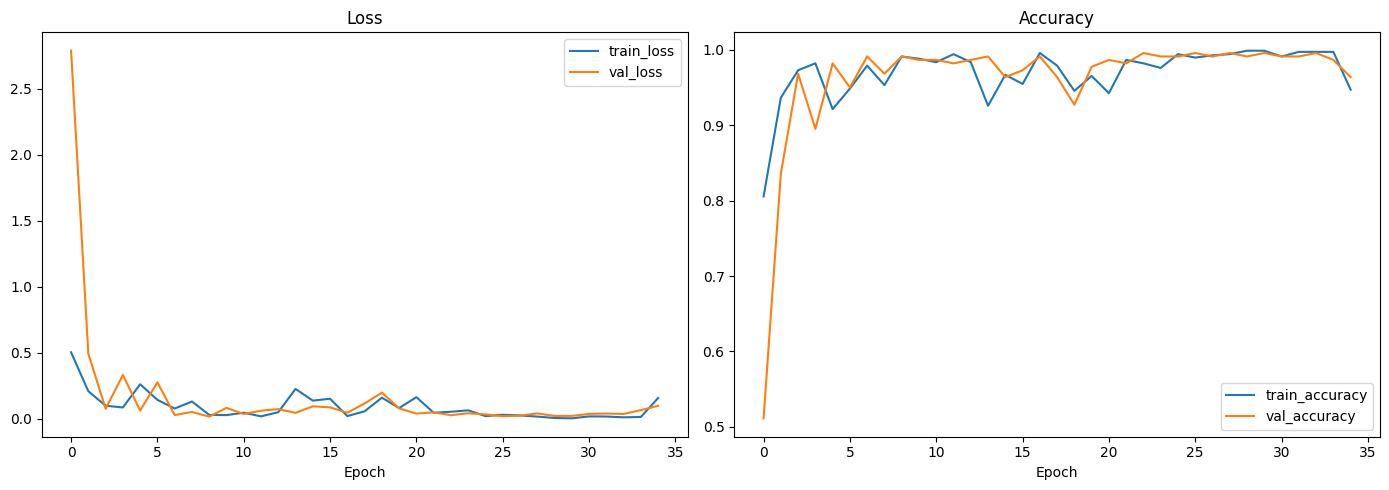

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="train_loss")
axes[0].plot(history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train_accuracy")
axes[1].plot(history["val_acc"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_mscvit_iqothnccd_224.png", dpi=150)
plt.show()

## 9. Final evaluation on TEST set (load best checkpoint)

Test loss: 0.0588  Test accuracy: 0.9864

Classification Report:
              precision    recall  f1-score   support

      normal     0.9881    1.0000    0.9940        83
      benign     1.0000    0.8750    0.9333        24
   malignant     0.9826    1.0000    0.9912       113

    accuracy                         0.9864       220
   macro avg     0.9902    0.9583    0.9729       220
weighted avg     0.9866    0.9864    0.9860       220

Test macro F1: 0.9729

Prediction distribution:
malignant    115
normal        84
benign        21
Name: count, dtype: int64


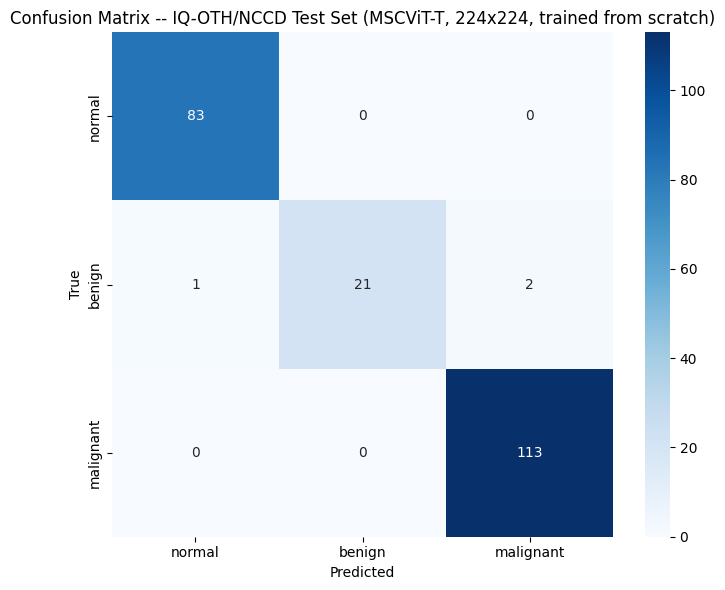


MSCViT-T (IQ-OTH/NCCD, 224x224, trained from scratch) test accuracy: 98.64%


In [16]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0
y_true_idx = []
y_pred_idx = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += images.size(0)
        y_true_idx.extend(labels.cpu().numpy().tolist())
        y_pred_idx.extend(preds.cpu().numpy().tolist())

test_loss = test_loss_sum / test_total
test_acc = test_correct / test_total
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- IQ-OTH/NCCD Test Set (MSCViT-T, 224x224, trained from scratch)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_mscvit_iqothnccd_224.png", dpi=150)
plt.show()

print(f"\nMSCViT-T (IQ-OTH/NCCD, 224x224, trained from scratch) test accuracy: {test_acc*100:.2f}%")